In [1]:
# Purpose:
# Reuse the validated LIF neuron dynamics from Exercise 0
# and import the required libraries again

# Source of Code and Justification:
# Exercise 1 keeps the same neuron model as Exercise 0:
# tau_m * du/dt = -u + R * I_total.

# Approach:
# - Add project root again
# - Import libraries again (NumPy, Matplotlib)
# - Import sparse-matrix tools for recurrent connectivity (csr_matrix)
# - Reuse LIF functions from Exercise 0

# What to say in Report:
# “For Exercise 1, we kept the same LIF membrane dynamics as in Exercise 0


import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Define figures directory
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

from src.lif import lif_euler_step, simulate_lif_population, lif_theoretical_fi

In [2]:
# Purpose:
# Initialize all Exercise 1 network, neuron, synaptic, noise, and simulation-time parameters
# before implementing recurrent E/I dynamics.

# Source of Code and Justification:
# Parameters are taken directly from the Exercise 1 statement in the project :
# NE = 1000, gamma = 0.25, p = 0.02, g = 5, J = 45 pC, tau_delay = 2 ms.
# The single-neuron LIF parameters are unchanged from Exercise 0 :
# theta = 20 mV, u_reset = -10 mV, R = 1 MOhm, dt = 0.5 ms, tau_m = 20 ms.
# Background input remains Poisson with n_bg = 25, as specified for subsequent exercises.

# Approach:
# - Define excitatory/inhibitory population sizes and total neuron count
# - Compute connections KE and KI with connection fraction p
# - Set recurrent synaptic strength and delay parameters
# - Reuse validated LIF neuron parameters from Ex.0
# - Keep stochastic background input settings unchanged
# - Define discrete time vector

# What to say in Report:
# “We initialized Exercise 1 using the assignment’s network and neuron parameters.
# Population sizes and sparse connections were set from (NE, gamma, p), while synaptic
# interactions are from (J, g, tau_delay). The LIF and background-noise parameters were kept
# identical to Exercise 0.”


# Network size from ex 1
NE = 1000
gamma = 0.25
NI = int(gamma * NE)
N = NE + NI

# Connectivity from ex 1
p = 0.02
KE = int(p * NE)
KI = int(p * NI)

# Synaptic parameters from ex 1
J = 45.0          # pC
g = 5.0
tau_delay = 2.0   # ms

# LIF parameters for a neuron (same as Ex.0)
theta = 20.0      # mV
u_reset = -10.0   # mV
R = 1.0           # MOhm
dt = 0.5          # ms
tau_m = 20.0      # ms

# Background input parameters (same as Ex.0)
n_bg = 25.0       # mean Poisson events per time step
bg_scale = 1.0    # nA per event

# Time (same as Ex.0.2)
T = 100.0         # ms 
n_steps = int(T / dt)
time = np.arange(n_steps) * dt

100%|██████████| 13/13 [00:00<00:00, 40.61it/s]


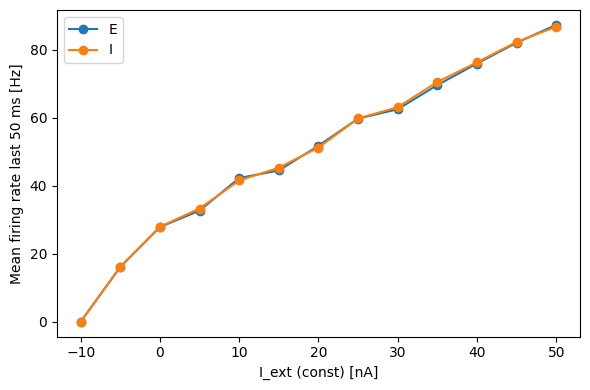

In [3]:
# Purpose:
# Create the sparse matrix W for the recurrent network (1.1) via the provided function we created.
# Reproduce Exercise 1.2 by sweeping constant external current I0 and measuring excitatory vs inhibitory
# population firing rates, following the Exercise 0.2.

# Source of Code and Justification:
# Exercise 1.2 asks for f–I curves of E and I on the same plot, using the same procedure as Exercise 0.2 :
# simulate for T = 100 ms and report mean firing rates averaged over the last 50 ms for each I0.
# The recurrent network uses the sparse weight matrix W generated in Exercise 1.1, with delayed synaptic
# feedback and Poisson background input as specified for the project.

# Approach:
# - Fix one connectivity W (same graph across all I0 values).
# - For each I0 in the sweep, run simulate_recurrent_exc_inh with identical neuron parameters 
#   and background statistics.
# - Use independent Poisson background realizations per I0.
# - Compute mean firing rates separately for E and Iover [50, 100) ms using population_rate_hz.
# - Plot both curves and save the figure.

# What to say in Report:
# “For Exercise 1.2, we measured population f–I curves for excitatory and inhibitory neurons under identical
# constant external input, using the Exercise 0.2 convention (mean rate over the final 50 ms during
# 100 ms simulation). A single sparse recurrent connectivity matrix was fixed across currents so differences
# reflect changes in external drive rather than graph variability.”

from tqdm import tqdm
from src.connectivity import generate_sparse_connectivity
from src.ei_unit import simulate_recurrent_exc_inh, population_rate_hz

W = generate_sparse_connectivity(NE, NI, KE, KI, J, g, seed=1)

rng = np.random.default_rng(0)
I_values = np.arange(-10, 55.0, 5.0)

rates_E = []
rates_I = []

for i0 in tqdm(I_values):
    rng = np.random.default_rng(rng.integers(0, 2**32 - 1))
    _, S = simulate_recurrent_exc_inh(
        W,
        NE,
        float(i0),
        T_ms=100.0,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=rng,
    )
    rE = population_rate_hz(S, slice(0, NE), dt, 50.0, 100.0)
    rI = population_rate_hz(S, slice(NE, NE + NI), dt, 50.0, 100.0)
    rates_E.append(rE)
    rates_I.append(rI)

plt.figure(figsize=(6, 4))
plt.plot(I_values, rates_E, "o-", label="E")
plt.plot(I_values, rates_I, "o-", label="I")
plt.xlabel("I_ext (const) [nA]")
plt.ylabel("Mean firing rate last 50 ms [Hz]")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex1_2_fi_curve_EI.png", dpi=300)
plt.show()
